In [1]:
import numpy as np
import networkx as nx

import os

%load_ext autoreload
%autoreload 2

In [181]:
Graphs = np.load("networks/powerlaw_m=1_p=0.2/graphs.npy", allow_pickle=True)
G = Graphs[9]

In [ ]:
results_dir = "hierarchical_metadata_20"
os.mkdir(results_dir)

In [188]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.searchers.hierarchical_searcher import HierarchicalSearcher
from Qommunity.iterative_searcher import IterativeSearcher

In [189]:
adv_sampler = AdvantageSampler(G, num_reads=100, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
it_searcher = IterativeSearcher(adv_sampler)

In [190]:
results = it_searcher.run_with_sampleset_info(num_runs=20, saving_path=f"{results_dir}/", return_metadata=True)

100%|██████████| 20/20 [18:08<00:00, 54.40s/it]


In [ ]:
from searchers.utils import HierarchicalRunMetadata
from dataclasses import fields


path = "./hierarchical_metadata_20/"

field_names = [f.name for f in fields(HierarchicalRunMetadata)]


sampleset_metadatas = []

print("Loading files...")

for run in range(7):
    hierarchical_run_metadata = HierarchicalRunMetadata.load_from_files(f"{path}_{run}")
    sampleset_metadatas.append(hierarchical_run_metadata)

Loading files...
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable


In [7]:
import numpy as np


communities = np.load(f"{path}_communities.npy", allow_pickle=True)
modularities = np.load(f"{path}_modularities.npy", allow_pickle=True)
division_modularities = np.load(f"{path}_division_modularities.npy", allow_pickle=True)

In [191]:
communities = results.communities
modularities = results.modularity
division_trees = results.division_tree
division_modularities = results.division_modularities
times = results.time
sampleset_metadatas = results.samplesets_data

In [8]:
mods = []
cbf_max = []
cbf_avg = []
max_cbf_div_mod = []
chain_strengths = []
comms_lens = []
energies = []
indices = []

for idx, sm in enumerate(sampleset_metadatas):
    # print(sm.chain_break_fraction)
    cbf_max.append(np.array(sm.chain_break_fraction).max())
    cbf_avg.append(np.array(sm.chain_break_fraction).mean())
    i = np.array(sm.chain_break_fraction).argmax()
    indices.append(i)

    chain_strengths.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods.append(modularities[idx])
    max_cbf_div_mod.append(division_modularities[idx][i+1])
    comms_lens.append(communities[idx])

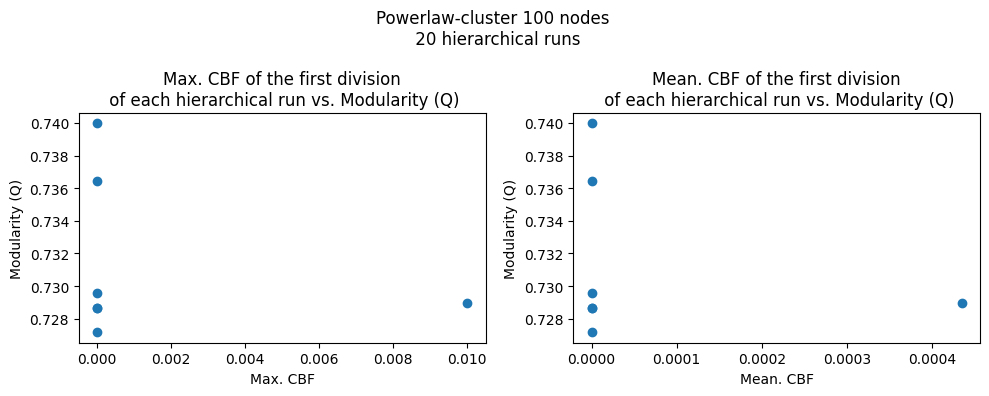

In [9]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Powerlaw-cluster 100 nodes \n 20 hierarchical runs")

ax[0].scatter(cbf_max, mods)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg, mods)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of the first division\n of each hierarchical run vs. Modularity (Q)");

plt.tight_layout()
plt.show()

In [81]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata

In [230]:
problem_ids = {}
energies = {}
qbits_involved = {}
mean_energies = {}
stds = {}
min_energies = {}
max_energies = {}
for run, sm in enumerate(sampleset_metadatas):
    problem_ids[run] = sm.problem_id
    en = []
    qbits = []
    me = []
    std = []
    for problem_id in sm.problem_id:
        pd = get_problem(problem_id=problem_id)
        en.append(pd.response.energies[0])
        qbits.append(len(pd.response.sampleset.variables))
        me.append(pd.response.sampleset.record.energy.mean())
        std.append(pd.response.sampleset.record.energy.std())
    energies[run] = en
    qbits_involved[run] = qbits
    mean_energies[run] = me
    stds[run] = std

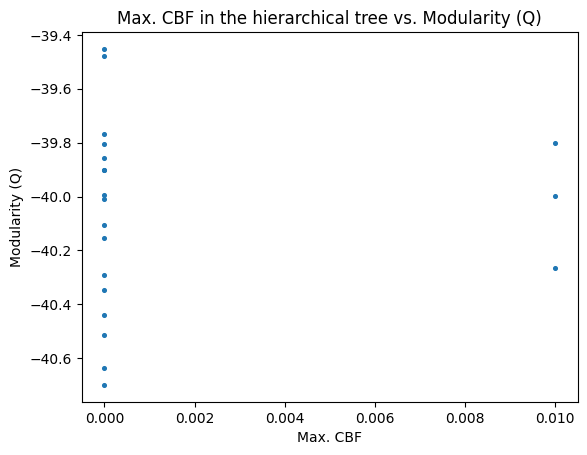

In [220]:
import matplotlib.pyplot as plt


plt.scatter(cbf_max, [v[0] for v in mean_energies.values()], s=7)
# plt.errorbar(cbf_max, [v[0] for v in mean_energies.values()], yerr=[v[0] for v in stds.values()])
# plt.yscale("log")
plt.ylabel("Modularity (Q)")
plt.xlabel("Max. CBF")
plt.title("Max. CBF in the hierarchical tree vs. Modularity (Q)");

In [211]:
from searchers.utils import HierarchicalRunMetadata

In [68]:
from utils import recover_ordering, plot_tree, get_extended_nodes

In [ ]:
pr_ids = 

In [71]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata


quadratics_mean = []
quadratics_std = []
linears_mean = []
linears_std = []
energies = []
for pr_id in pr_ids:
    pd = get_problem(pr_id)
    quads = np.array(list(pd.problem["quadratic"].values()))
    quadratics_mean.append(np.mean(quads))
    quadratics_std.append(np.std(quads))
    linears = np.array(list(pd.problem["linear"].values()))
    linears_mean.append(np.mean(linears))
    linears_std.append(np.std(linears))
    energies.append(pd.response.energies[0])

NameError: name 'pr_ids' is not defined

In [9]:
fe = ["sampleset_adv.pkl", "sampleset_adv_serializable.pkl", "sampleset_adv.npy"]

In [ ]:
import os
import re


hashes = list(nodes.keys())

result_files = []
result_files_handles = []
for root, dirs, files in os.walk("."):
    for file in files:
        match = re.search(r"comm_hash=(.*?)__id", file)
        if match:
            comm_hash = int(match.group(1))
            # pattern = rf"^.*comm_hash={comm_hash}.*_sampleset_adv.pkl$"
            pattern = rf"^.*comm_hash={comm_hash}.*"
            result_handle = re.search(pattern, file)
            if result_handle:
                # result_handle = re.split(rf"(_{fe[0]})$", result_handle.group(0))
                result_handle = re.split("sampleset", result_handle.group(0))
                if comm_hash in hashes:
                    result_files.append(os.path.join(root, file))
                    result_files_handles.append(result_handle[0])

In [18]:
for root, dirs, files in os.walk("."):
    for file in files:
        match = re.search(r"comm_hash=(.*?)__id", file)
        if match:
            comm_hash = int(match.group(1))
            # pattern = rf"^.*comm_hash={comm_hash}.*_sampleset_adv.pkl$"
            pattern = rf"^.*comm_hash={comm_hash}.*"
            result_handle = re.search(pattern, file)
            print(result_handle)
            result_handle = re.split("sampleset", result_handle.group(0))
            print(result_handle)

AttributeError: 'NoneType' object has no attribute 'group'

In [26]:
from searchers.utils import HierarchicalRunMetadata
from dataclasses import fields

In [36]:
path = "saving"
field_names = list(HierarchicalRunMetadata.__dataclass_fields__.keys())

In [39]:
import pickle
import os
from searchers.utils import HierarchicalRunMetadata


path = "./saving"

field_names = [f.name for f in fields(HierarchicalRunMetadata)]


loaded_data = {}

print("Loading files...")

for field_name in field_names:
    filename = f"exp_{field_name}.pkl" 
    file_path = os.path.join(path, filename)
    
    if os.path.exists(file_path):
        try:
            with open(file_path, 'rb') as f:
                loaded_data[field_name] = pickle.load(f) 
            print(f"✅ Successfully loaded: {filename}")
        except Exception as e:
            print(f"❌ Error loading {filename}: {e}")
    else:
        print(f"⚠️ File not found (skipping): {filename}")

# --- Result ---
print("\n--- Summary ---")
print(f"Total fields loaded: {len(loaded_data)}")

Loading files...
✅ Successfully loaded: exp_dwave_sampleset_metadata.pkl
✅ Successfully loaded: exp_time_measurements.pkl
❌ Error loading exp_dwave_sampleset.pkl: EmbeddedStructure is immutable
✅ Successfully loaded: exp_timing.pkl
✅ Successfully loaded: exp_problem_id.pkl
✅ Successfully loaded: exp_community_hash.pkl
✅ Successfully loaded: exp_chain_strength.pkl
✅ Successfully loaded: exp_chain_break_fraction.pkl
✅ Successfully loaded: exp_chain_break_method.pkl
❌ Error loading exp_embedding.pkl: EmbeddedStructure is immutable
✅ Successfully loaded: exp_warnings.pkl
⚠️ File not found (skipping): exp_community.pkl

--- Summary ---
Total fields loaded: 9


In [52]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata
from dwave.inspector.adapters import enable_data_capture


enable_data_capture()

{}